In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("../data/phase3_feature_engineering.csv")

In [3]:
X = df.drop(columns=['churn','mobile_number'])
y = df['churn']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
cols_to_drop = X_train.select_dtypes(include='object').columns

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [6]:
X_train.dtypes.value_counts()

float64    156
int64       26
Name: count, dtype: int64

In [7]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [8]:
y_train_res.value_counts()

churn
0    21934
1    21934
Name: count, dtype: int64

In [9]:
## now we will do feature scaling (needed for PCA)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [10]:
print(len(X_train_scaled))
print(len(X_test_scaled))

43868
6003


In [11]:
## PCA
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [12]:
print("Number of PCA components:", pca.n_components_)

Number of PCA components: 72


#### Part 1 — Prediction Model (PCA + Random Forest)

##### This model is the black box high-accuracy model.

In [13]:
from sklearn.model_selection import GridSearchCV

## random forest

rf = RandomForestClassifier(random_state=42)


param_grid = {
    'n_estimators':[200,300],
    'max_depth':[10,20,None],
    'class_weight':[None,'balanced',{0:1,1:3}]
}

grid = GridSearchCV(
    rf,
    param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_pca, y_train_res)

rf_model = grid.best_estimator_

In [14]:
## predictions

y_pred = rf_model.predict(X_test_pca)

In [15]:
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(6003,))

In [16]:
## evaluation

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[4137 1347]
 [  86  433]]
              precision    recall  f1-score   support

           0       0.98      0.75      0.85      5484
           1       0.24      0.83      0.38       519

    accuracy                           0.76      6003
   macro avg       0.61      0.79      0.61      6003
weighted avg       0.92      0.76      0.81      6003



#### Part 2 — Insight Model (Logistic Regression)
##### This model explains why customers churn.

In [17]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_res, y_train_res)

c:\Data-Science-Projects\customer churn analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [18]:
print(len(X.columns))
print(len(log_model.coef_[0]))
print(len(X_train_res.columns))

191
182
182


In [19]:
## feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train_res.columns,
    "Importance": log_model.coef_[0]
})

In [20]:
## sort on the basis of feature sort by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [21]:
feature_importance.head(20)

,Feature,Importance
172,rech_cnt_avg_6_7,1.114246
162,avg_rech_amt_6_7,0.893264
174,rech_amt_avg_6_7,0.893264
112,total_rech_data_6,0.354914
118,count_rech_2g_6,0.295810
175,rech_amt_drop,0.252132
173,rech_freq_drop,0.201809
113,total_rech_data_7,0.109039
122,count_rech_3g_7,0.070725
121,count_rech_3g_6,0.059104


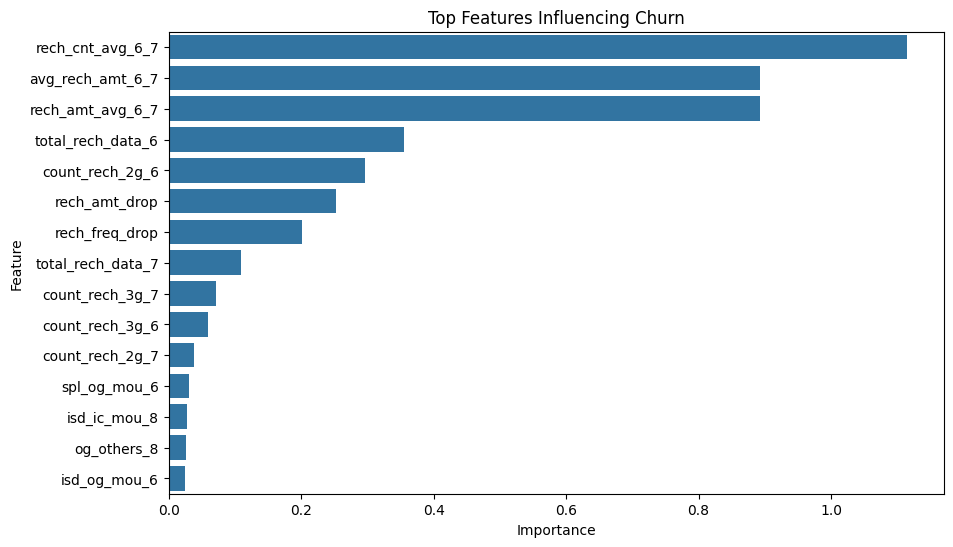

In [22]:
## visualization

import seaborn as sns
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top Features Influencing Churn")
plt.show()

#### Phase6 - choosing the right metric --> model eval with recall

In [23]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

In [24]:
## predict on test data

y_pred = rf_model.predict(X_test_pca)

In [25]:
print(confusion_matrix(y_test, y_pred))

[[4137 1347]
 [  86  433]]


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85      5484
           1       0.24      0.83      0.38       519

    accuracy                           0.76      6003
   macro avg       0.61      0.79      0.61      6003
weighted avg       0.92      0.76      0.81      6003



In [27]:
## recall explicit calculation

recall = recall_score(y_test, y_pred)

print("Recall for churn class:", recall)

Recall for churn class: 0.8342967244701349


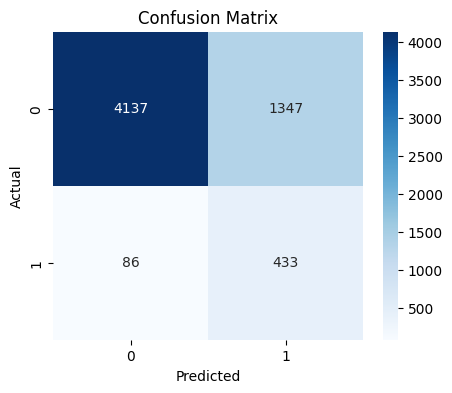

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()